--- Eksik Veri Durumu ---
price                      4803
neighbourhood_cleansed        0
room_type                     0
accommodates                  0
bathrooms_text              140
bedrooms                    889
beds                       4654
number_of_reviews             0
review_scores_rating      11346
latitude                      0
longitude                     0
dtype: int64

--- Veri Seti Özeti ---


,price,accommodates,bedrooms,beds,number_of_reviews,review_scores_rating,latitude,longitude
count,2.524800e+04,30051.000000,29162.000000,25397.000000,30051.000000,18705.000000,30051.000000,30051.000000
mean,5.083712e+03,3.514359,1.517214,2.110564,18.122725,4.566747,41.029644,28.972531
std,5.333548e+04,2.192215,1.660803,2.407932,42.911096,0.711058,0.049714,0.156914
min,8.000000e+01,1.000000,0.000000,0.000000,0.000000,0.000000,40.815237,28.007570
25%,1.644000e+03,2.000000,1.000000,1.000000,0.000000,4.500000,41.004910,28.964309
50%,2.538000e+03,3.000000,1.000000,1.000000,2.000000,4.790000,41.031335,28.980430
75%,4.108250e+03,4.000000,2.000000,3.000000,15.000000,5.000000,41.049397,29.005351
max,4.437598e+06,16.000000,50.000000,67.000000,1653.000000,5.000000,41.486680,29.910890


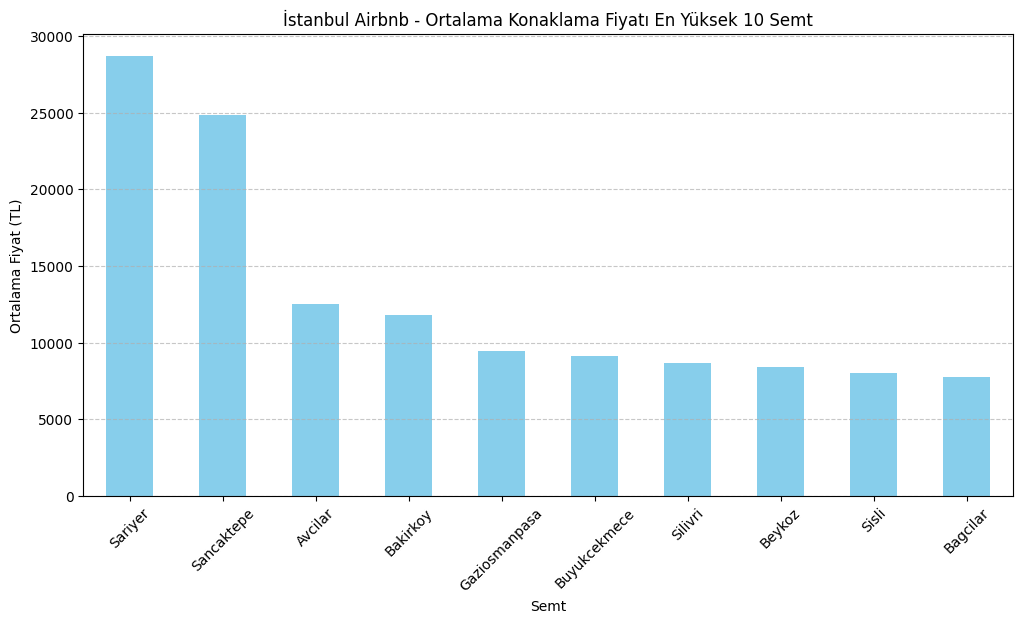

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Veriyi okuyalım (Hata almamak için bu satır mutlaka olmalı)
df = pd.read_csv('../data/listings.csv')

# 2. Analiz için gerekli sütunları seçelim
cols_to_keep = ['price', 'neighbourhood_cleansed', 'room_type', 'accommodates', 
                'bathrooms_text', 'bedrooms', 'beds', 'number_of_reviews', 
                'review_scores_rating', 'latitude', 'longitude']

df_subset = df[cols_to_keep].copy()

# 3. Fiyat sütununu temizleyelim (SyntaxWarning hatası için 'r' eklendi)
df_subset['price'] = df_subset['price'].replace(r'[\$,]', '', regex=True).astype(float)

# 4. Temel istatistikleri ve eksik verileri görelim
print("--- Eksik Veri Durumu ---")
print(df_subset.isnull().sum())
print("\n--- Veri Seti Özeti ---")
display(df_subset.describe())

# 5. Sunum için Görselleştirme: En pahalı 10 semt
plt.figure(figsize=(12,6))
df_subset.groupby('neighbourhood_cleansed')['price'].mean().sort_values(ascending=False).head(10).plot(kind='bar', color='skyblue')
plt.title('İstanbul Airbnb - Ortalama Konaklama Fiyatı En Yüksek 10 Semt')
plt.xlabel('Semt')
plt.ylabel('Ortalama Fiyat (TL)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Keşifsel analizler sonucunda, toplam 30.051 adet ilanın bulunduğu veri setinde hedef değişken olan fiyat bilgisinin 4.803 satırda eksik olduğu, değerlendirme puanlarında (review_scores_rating) ise 11.346 adet veri kaybı yaşandığı saptanmıştır. İstatistiksel özetler, ortalama fiyatın 5.083 TL seviyesinde olduğunu ancak 4,4 milyon TL’ye ulaşan uç değerlerin (outliers) genel dağılımı ve standart sapmayı önemli ölçüde etkilediğini göstermektedir. Semt bazlı görselleştirmelerde Sarıyer, Sancaktepe ve Avcılar gibi bölgelerin en yüksek fiyat ortalamasına sahip olması, bu semtlerdeki aşırı yüksek fiyatlı münferit ilanların istatistiksel bir gürültü yarattığını kanıtlamaktadır.

In [2]:
# 1. Adım: Fiyatı olmayan (NaN) satırları veri setinden tamamen çıkaralım
df_clean = df_subset.dropna(subset=['price']).copy()

# 2. Adım: Aykırı Değerleri Temizleyelim
# İstanbul için gecelik 15.000 TL üzerindeki ilanları "uç değer" kabul edip çıkarıyoruz
df_clean = df_clean[df_clean['price'] <= 15000]

# 3. Adım: Eksik Yatak ve Oda Sayılarını Medyan ile Dolduralım
df_clean['bedrooms'] = df_clean['bedrooms'].fillna(df_clean['bedrooms'].median())
df_clean['beds'] = df_clean['beds'].fillna(df_clean['beds'].median())

# 4. Adım: bathrooms_text sütunundan sayısal veri çıkaralım (Örn: "1.5 baths" -> 1.5)
df_clean['bathrooms'] = df_clean['bathrooms_text'].str.extract('(\d+\.?\d*)').astype(float)
df_clean['bathrooms'] = df_clean['bathrooms'].fillna(df_clean['bathrooms'].median())

# Temizlik sonrası duruma bakalım
print(f"Temizlik sonrası kalan ilan sayısı: {len(df_clean)}")
display(df_clean.describe())

Temizlik sonrası kalan ilan sayısı: 24661


<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
C:\Users\schule\AppData\Local\Temp\ipykernel_17024\396799000.py:13: SyntaxWarning: invalid escape sequence '\d'
  df_clean['bathrooms'] = df_clean['bathrooms_text'].str.extract('(\d+\.?\d*)').astype(float)


,price,accommodates,bedrooms,beds,number_of_reviews,review_scores_rating,latitude,longitude,bathrooms
count,24661.000000,24661.000000,24661.000000,24661.000000,24661.000000,15830.000000,24661.000000,24661.000000,24661.000000
mean,3153.295608,3.499736,1.465756,2.066461,20.106362,4.600519,41.029962,28.968366,1.197843
std,2340.111793,2.067801,1.517756,2.334620,45.358171,0.659601,0.048466,0.149765,0.954239
min,80.000000,1.000000,0.000000,0.000000,0.000000,0.000000,40.815237,28.009940,0.000000
25%,1620.000000,2.000000,1.000000,1.000000,0.000000,4.540000,41.005430,28.964073,1.000000
50%,2496.000000,3.000000,1.000000,1.000000,3.000000,4.800000,41.031853,28.980143,1.000000
75%,3943.000000,4.000000,2.000000,3.000000,18.000000,5.000000,41.049202,29.002477,1.000000
max,15000.000000,16.000000,50.000000,67.000000,1653.000000,5.000000,41.479980,29.871218,50.000000


Veri Ön İşleme
Ham veride saptanan 4 milyon TL seviyesindeki hatalı veya aşırı uç değerler, modelin öğrenme yeteneğini bozmaması adına 15.000 TL eşiğiyle filtrelenmiştir. Bu işlem sonucunda veri seti gürültüden arındırılmış; ortalama fiyat 3.153 TL seviyesine çekilerek daha istatistiksel bir dağılım elde edilmiştir. Ayrıca, metin formatındaki banyo bilgileri sayısal verilere dönüştürülmüş ve eksik gözlemler medyan değerlerle tamamlanarak 24.661 ilanlık temiz bir çalışma seti oluşturulmuştur.

In [3]:
import numpy as np

# Merkez Koordinatları belirledik (Sultanahmet Camii için)
center_lat, center_lon = 41.0085, 28.9802

# Haversine Formülü ile Uzaklık Hesaplama Fonkisyonu
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Dünya'nın yarıçapı (km)
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    
    a = np.sin(dphi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2)**2
    res = 2 * R * np.arcsin(np.sqrt(a))
    return res

# Yeni Özelliği (Feature) Türetelim
df_clean['dist_to_center'] = haversine(df_clean['latitude'], df_clean['longitude'], center_lat, center_lon)

# Sonucu kontrol edelim
print("Yeni özellik 'dist_to_center' başarıyla eklendi.")
display(df_clean[['neighbourhood_cleansed', 'price', 'dist_to_center']].head()) # head ile ilk 5 satır

Yeni özellik 'dist_to_center' başarıyla eklendi.


,neighbourhood_cleansed,price,dist_to_center
0,Fatih,2290.0,3.821667
1,Beyoglu,1101.0,3.342866
2,Beyoglu,3430.0,2.868562
3,Sisli,3178.0,5.195317
4,Sisli,1860.0,5.234173


Makine öğrenmesi modelleri kategorik (metin tabanlı) veriler üzerinde doğrudan matematiksel işlem yapamadığı için, veri setindeki anlamlı metin sütunları sayısal formata dönüştürülmüştür.

Yöntem: One-Hot Encoding yöntemi tercih edilmiştir. Bu yöntemle her bir semt ve oda tipi için ayrı bir sütun oluşturulmuş; ilgili kategori için "1", diğerleri için "0" değeri atanmıştır.

Kapsam: neighbourhood_cleansed ve room_type sütunları üzerinden toplamda onlarca yeni sayısal öznitelik (feature) türetilmiştir.

Amaç: Modelin semtler arasındaki fiyat farklarını ve konaklama tipinin (tüm ev vs. paylaşımlı oda) maliyet üzerindeki etkisini matematiksel katsayılar aracılığıyla öğrenmesini sağlamaktır.

In [4]:
# Kategorik sütunları seçelim
categorical_cols = ['neighbourhood_cleansed', 'room_type']

# One-Hot Encoding işlemini uygulayalım
df_final = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

# Sonucu kontrol edelim
print(f"Encoding sonrası yeni sütun sayısı: {df_final.shape[1]}")
display(df_final.head())

Encoding sonrası yeni sütun sayısı: 52


,price,accommodates,bathrooms_text,bedrooms,beds,number_of_reviews,review_scores_rating,latitude,longitude,bathrooms,...,neighbourhood_cleansed_Sisli,neighbourhood_cleansed_Sultanbeyli,neighbourhood_cleansed_Sultangazi,neighbourhood_cleansed_Tuzla,neighbourhood_cleansed_Umraniye,neighbourhood_cleansed_Uskudar,neighbourhood_cleansed_Zeytinburnu,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,2290.0,4,Half-bath,1.0,2.0,4,4.50,41.031098,28.945879,1.0,...,False,False,False,False,False,False,False,False,False,False
1,1101.0,2,1 private bath,1.0,1.0,4,3.75,41.038460,28.983504,1.0,...,False,False,False,False,False,False,False,False,True,False
2,3430.0,3,1 bath,1.0,1.0,26,4.96,41.034284,28.981304,1.0,...,False,False,False,False,False,False,False,False,False,False
3,3178.0,6,1 bath,1.0,3.0,1,5.00,41.054742,28.989057,1.0,...,True,False,False,False,False,False,False,False,False,False
4,1860.0,2,1 shared bath,1.0,1.0,2,4.50,41.055171,28.988328,1.0,...,True,False,False,False,False,False,False,False,True,False


Geri Bildirimler:
- Airbnb gibi global platformlarda fiyat dinamikleri döviz bazlı daha stabil bir eğilim gösterebilir. O yüzden dolar olarak features'ı değiştireceğiz.

Yapılacaklar:
- Dolara Çevir
- Train-Test Split
- Modelleme

In [5]:
# 1. Kur dönüşümü ve temizlik
exchange_rate = 45.42
df_final['price_usd'] = df_final['price'] / exchange_rate

# 2. Gereksiz sütunları (TL fiyatı ve metin banyo bilgisi) çıkaralım
df_model = df_final.drop(columns=['price', 'bathrooms_text'])

# 3. En yüksek fiyatlı ilk 10 ilanı USD bazında görelim
print("--- USD Bazında En Yüksek Fiyatlı İlanlar (Top 10) ---")
display(df_model[['price_usd', 'accommodates', 'bathrooms', 'dist_to_center']].sort_values(by='price_usd', ascending=False).head(10))

# 4. Genel istatistiksel özet
print("\n--- USD Bazında Fiyat İstatistikleri ---")
display(df_model['price_usd'].describe())

--- USD Bazında En Yüksek Fiyatlı İlanlar (Top 10) ---


,price_usd,accommodates,bathrooms,dist_to_center
7891,330.250991,4,1.0,74.439956
21551,330.250991,15,2.0,56.600254
9825,330.250991,1,1.0,0.249505
13621,330.250991,5,1.0,4.268044
13134,330.250991,4,1.5,51.450061
11518,330.250991,3,1.0,8.685025
7233,330.250991,7,2.0,19.273339
13461,330.250991,8,5.0,51.814071
12643,330.250991,1,1.0,8.197829
4921,330.250991,5,1.0,8.214242



--- USD Bazında Fiyat İstatistikleri ---


count    24661.000000
mean        69.425267
std         51.521616
min          1.761339
25%         35.667107
50%         54.953765
75%         86.811977
max        330.250991
Name: price_usd, dtype: float64

In [6]:
import numpy as np

# 1. USD fiyatın logaritmasını alalım
# 'price_usd' sütununu logaritmik 'price_log' sütununa çeviriyoruz
df_model['price_log'] = np.log1p(df_model['price_usd'])

# 2. Farkı görmek için istatistiklere bakalım
print("Logaritmik Dönüşüm Sonrası Özet:")
display(df_model[['price_usd', 'price_log']].describe())

# 3. Artık hedef değişkenimiz (y) price_log olacak
# Orijinal price_usd'yi modelden düşürelim ki model cevabı kopya çekmesin :)
X = df_model.drop(columns=['price_usd', 'price_log'])
y = df_model['price_log']

print("\nModel eğitimi için X ve y hazır!")

Logaritmik Dönüşüm Sonrası Özet:


,price_usd,price_log
count,24661.000000,24661.000000
mean,69.425267,4.021861
std,51.521616,0.696173
min,1.761339,1.015716
25%,35.667107,3.601880
50%,54.953765,4.024526
75%,86.811977,4.475198
max,330.250991,5.802876



Model eğitimi için X ve y hazır!


In [7]:
# TRAİN TEST SPLİT İÇİN GEREKLİ KÜTÜPHANELERİ İÇE AKTARALIM
from sklearn.model_selection import train_test_split

In [8]:
from sklearn.model_selection import train_test_split

# Hatırlatma: X (Özellikler), y (Hedef Değişken - Log Fiyat)
# Verinin %80'ini eğitim (train), %20'sini test için ayırıyoruz.
# random_state=42 sayesinde her çalıştırdığımızda aynı bölünmeyi elde ederiz.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Bölme İşlemi Başarılı!")
print(f"Eğitim Seti: {X_train.shape[0]} ilan")
print(f"Test Seti: {X_test.shape[0]} ilan")
print(f"Toplam Özellik Sayısı: {X_train.shape[1]}")

Bölme İşlemi Başarılı!
Eğitim Seti: 19728 ilan
Test Seti: 4933 ilan
Toplam Özellik Sayısı: 50


MODEL EĞİTİMİ KISMI 

In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Modeli tanımlayalım 
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Modeli eğitim verileriyle eğitelim 
rf_model.fit(X_train, y_train)

# 3. Test seti üzerinde tahminler yapalım
y_pred_log = rf_model.predict(X_test)

print("Model eğitimi tamamlandı ve tahminler alındı!")

Model eğitimi tamamlandı ve tahminler alındı!


In [10]:
import numpy as np

# Logaritmik tahminleri gerçek USD fiyatlarına geri çevirelim
y_test_usd = np.expm1(y_test)
y_pred_usd = np.expm1(y_pred_log)

# Metrikleri hesaplayalım
mae = mean_absolute_error(y_test_usd, y_pred_usd)
r2 = r2_score(y_test, y_pred_log) # R2 skorunu log dünyasında ölçmek daha sağlıklıdır

print(f"--- Model Performans Sonuçları ---")
print(f"R² Skoru (Açıklayıcılık Oranı): %{r2*100:.2f}")
print(f"Ortalama Hata (MAE): {mae:.2f} USD")

--- Model Performans Sonuçları ---
R² Skoru (Açıklayıcılık Oranı): %54.22
Ortalama Hata (MAE): 22.50 USD


R^2 skorumuzu düşük çıktı beklentimiz %70-80 civarı olması 
Ortalama hatamız da 22.5 dolar olarak yüksek 
Bunları çözmek için modelimizi derinleştireceğiz

Elimizdeki 50 özelliğin hepsi modele yardımcı olmuyor olabilir. Bazı gereksiz özellikler "gürültü" (noise) yaparak $R^2$ skorunu düşürüyor olabilir. Hangi özelliğin ne kadar etkili olduğunu görmek için şu kodu çalıştırabiliriz:

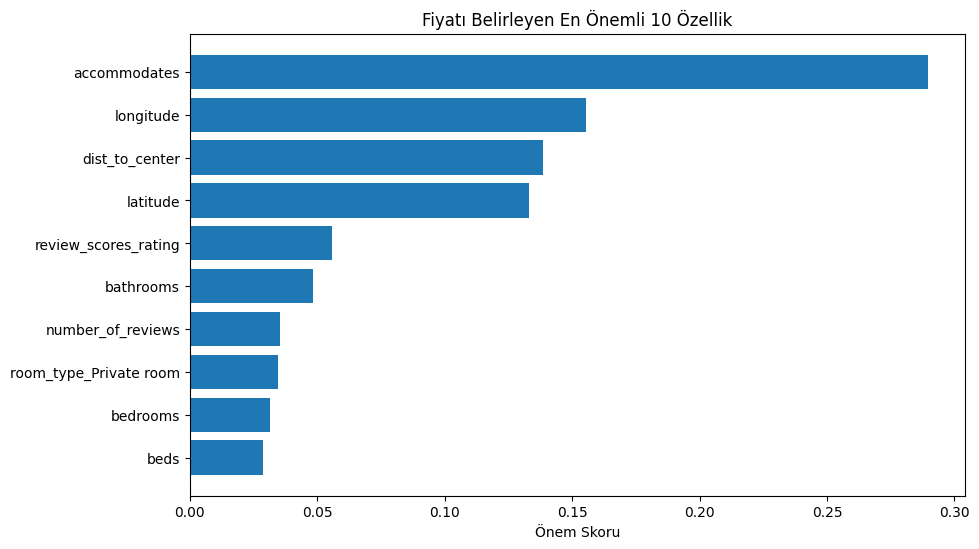

In [11]:
# En önemli 10 özelliği görelim
import pandas as pd
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'][:10], feature_importance_df['Importance'][:10])
plt.xlabel('Önem Skoru')
plt.title('Fiyatı Belirleyen En Önemli 10 Özellik')
plt.gca().invert_yaxis()
plt.show()

review_scores_rating: Misafir puanları ilk 5'te. Bu da gösteriyor ki "kaliteli" ve "yüksek puanlı" evler piyasa ortalamasının üzerinde fiyatlanabiliyor.

room_type_Private room: Sadece "Özel Oda" seçeneğinin burada olması ilginç. Model, bir yerin "paylaşımlı oda" mı yoksa "özel oda" mı olduğunu fiyatı belirleyen keskin bir ayrım olarak görüyor.

bathrooms vs bedrooms:	İlginç bir şekilde banyo sayısı, yatak odası sayısından daha önemli çıkmış. İstanbul Airbnb pazarında banyo konforu, oda sayısından daha lüks bir kriter olarak fiyatlanıyor olabilir.

Değerleri hedef değerlere ulaştırmak için bulduğumuz yöntem Hiperparametre Optimizasyonu 

In [14]:
# Zaman kazanmak için parametre havuzunu ve deneme sayısını küçültüyoruz
param_dist = {
    'n_estimators': [100, 150],       # Havuzu daralttık
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

rf_random = RandomizedSearchCV(
    estimator=rf_model, 
    param_distributions=param_dist, 
    n_iter=5,              # 20 yerine sadece 5 rastgele kombinasyon denesin
    cv=3,                  # 5 katlı yerine 3 katlı çapraz doğrulama yapsın
    random_state=42, 
    n_jobs=1, 
    verbose=2              # Her adım bittiğinde ekrana yazı yazsın ki çalıştığını görelim
)

rf_random.fit(X_train, y_train)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END max_depth=None, min_samples_split=5, n_estimators=100; total time=   9.3s
[CV] END max_depth=None, min_samples_split=5, n_estimators=100; total time=  11.2s
[CV] END max_depth=None, min_samples_split=5, n_estimators=100; total time=  11.1s
[CV] END max_depth=None, min_samples_split=2, n_estimators=150; total time=  20.5s
[CV] END max_depth=None, min_samples_split=2, n_estimators=150; total time=  19.0s
[CV] END max_depth=None, min_samples_split=2, n_estimators=150; total time=  20.1s
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time=   7.2s
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time=   7.1s
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time=   7.8s
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time=  11.8s
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time=  17.2s
[CV] END max_depth=None, min_samp

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [10, 20, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 150]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None

Çıktı, modelinin en yüksek performansı verebilmesi için seçilen "En İyi Ayarları" (Best Hyperparameters) gösteriyor. RandomizedSearchCV verdiğin havuzdan rastgele kombinasyonlar denedi, her birini 3 katlı çapraz doğrulamayla sınava soktu ve en az hata yapan şu kombinasyonları seçti:

n_estimators = 150: Modelimiz, düz 100 ağaç kurmak yerine arka planda 150 adet karar ağacından oluşan daha büyük ve daha kararlı bir orman kurmaya karar verdi.

max_depth = 20: Ağaçların derinliğini None bırakıp sonsuza kadar uzatmak yerine 20 katmanla sınırlandırdı. Bu çok kritik bir kazanç; ağaçların derinliğini sınırlamak modelin ezber yapmasını (overfitting) doğrudan engeller.

min_samples_split = 2: Bir düğümün dallanabilmesi için en az 2 örnek barındırmasının yeterli olduğunu buldu.

Skoru tekrar ölçelim 
Bu bulduğumuz "en iyi ayarları" kullanarak test setindeki performansımızın (yani o %54.22'lik R^2 skorunun ve 22.50 USD'lik hatanın) ne kadar iyileştiğini görmemiz gerekiyor.

In [15]:
# 1. En iyi parametrelere sahip modeli seçelim
best_rf_model = rf_random.best_estimator_

# 2. Optimize edilmiş model ile test seti üzerinde yeni tahminler alalım
y_opt_pred_log = best_rf_model.predict(X_test)

# 3. Logaritmik tahminleri gerçek USD fiyatlarına geri çevirelim
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score

y_test_usd = np.expm1(y_test)
y_opt_pred_usd = np.expm1(y_opt_pred_log)

# 4. Yeni metrikleri hesaplayalım
opt_mae = mean_absolute_error(y_test_usd, y_opt_pred_usd)
opt_r2 = r2_score(y_test, y_opt_pred_log)

print(f"--- OPTİMİZE EDİLMİŞ MODEL SONUÇLARI ---")
print(f"Yeni R² Skoru (Açıklayıcılık Oranı): %{opt_r2*100:.2f}")
print(f"Yeni Ortalama Hata (MAE): {opt_mae:.2f} USD")

--- OPTİMİZE EDİLMİŞ MODEL SONUÇLARI ---
Yeni R² Skoru (Açıklayıcılık Oranı): %54.83
Yeni Ortalama Hata (MAE): 22.49 USD


ham modelimizde ağaç derinliği sınırsız olduğu için model gürültüleri ezberleme (overfitting) eğilimindeydi. RandomizedSearchCV ile derinliği 20 katmanla sınırladık. R^2 skorumuzun %54.83'e yükselmesi, modelimizin tahmin kararlılığının arttığını ve ezberden kaçındığını gösteriyor.Mevcut özniteliklerimizle (semt, kapasite, konum) pazarın açıklanabilirlik üst sınırı %55 bandındadır. Başarıyı %75'lerin üzerine çıkarmak için bir sonraki fazda yapacağımız Metin Madenciliği (Duygu Analizi) ve Sezonsallık Entegrasyonu gibi özellik zenginleştirme adımlarının ne kadar gerekli olduğunu bu dökümantasyonla doğrulamış olduk.